# 03 - Model Experiments

This notebook trains and evaluates the two main modeling approaches:
1. Fine-tuned ResNet-18 (reference implementation)
2. DenseNet-Attention (student-developed model)

All runs are optionally tracked with Weights & Biases (if configured in .env).

In [1]:
import sys
sys.path.insert(0, "..")

import os
import copy
import random
import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from torch.optim.lr_scheduler import CosineAnnealingLR
from pathlib import Path

from src.data import get_dataloaders
from src.models import get_model, get_optimizer, FocalLoss
from src.train import train_one_epoch, validate
from src.evaluate import (
    evaluate_model, plot_confusion_matrix, plot_roc_curve,
    plot_training_history, generate_gradcam, plot_gradcam_grid,
)
from src.utils import set_seed, get_device, load_config, save_results, count_parameters
from src.wandb_utils import (
    setup_wandb, wandb_init, wandb_log, wandb_summary,
    wandb_log_image, wandb_log_artifact, wandb_finish,
)

plt.rcParams["figure.dpi"] = 100
sns.set_style("whitegrid")

load_dotenv("../.env")
USE_WANDB = setup_wandb()

config = load_config("../configs/default.yaml")
device = get_device()
DATA_ROOT = "../data/chest_xray"
SEED = config["reproducibility"]["seed"]

print(f"Device: {device}")
print(f"Wandb tracking: {'enabled' if USE_WANDB else 'disabled'}")

wandb: Currently logged in as: nevin-helfenstein (medimg-pneumonia-detection) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[wandb] Logged in. Project: medimg-pneumonia-detection
Device: cuda
Wandb tracking: enabled


In [2]:
set_seed(SEED)

dataloaders = get_dataloaders(
    DATA_ROOT,
    augmentation="standard",
    image_size=config["data"]["image_size"],
    batch_size=config["training"]["batch_size"],
    val_split=config["data"]["val_split"],
    num_workers=0,
    seed=SEED,
)

print(f"Dataset info: {dataloaders['info']}")

Dataset info: {'train_size': 4447, 'val_size': 785, 'test_size': 624, 'train_class_dist': {np.int64(0): np.int64(1147), np.int64(1): np.int64(3300)}, 'val_class_dist': {np.int64(0): np.int64(202), np.int64(1): np.int64(583)}, 'test_class_dist': {np.int64(0): np.int64(234), np.int64(1): np.int64(390)}, 'class_names': ['NORMAL', 'PNEUMONIA']}


In [3]:
def train_with_wandb(
    model_name, model, dataloaders, device, config,
    experiment_name, use_focal=False,
):
    """Train a model with optional wandb tracking."""
    wandb_config = {
        "model": model_name,
        "epochs": config["training"]["num_epochs"],
        "batch_size": config["training"]["batch_size"],
        "learning_rate": config["training"]["learning_rate"],
        "weight_decay": config["training"]["weight_decay"],
        "augmentation": "standard",
        "image_size": config["data"]["image_size"],
        "use_focal_loss": use_focal,
        "seed": SEED,
        "train_size": dataloaders["info"]["train_size"],
        **count_parameters(model),
    }

    run = wandb_init(
        name=experiment_name,
        config=wandb_config,
        reinit=True,
    ) if USE_WANDB else None

    if use_focal:
        criterion = FocalLoss(
            alpha=config["model"].get("focal_loss_alpha", 0.6),
            gamma=config["model"].get("focal_loss_gamma", 2.0),
        )
    else:
        train_info = dataloaders["info"]["train_class_dist"]
        n_pos = train_info.get(1, 1)
        n_neg = train_info.get(0, 1)
        pos_weight = torch.tensor([n_neg / n_pos]).to(device)
        criterion = torch.nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    lr = config["training"]["learning_rate"]
    wd = config["training"]["weight_decay"]
    optimizer = get_optimizer(model, model_name, lr=lr, weight_decay=wd)
    scheduler = CosineAnnealingLR(optimizer, T_max=config["training"]["num_epochs"])

    model = model.to(device)
    best_auroc = 0.0
    best_state = copy.deepcopy(model.state_dict())
    patience = config["training"]["early_stopping_patience"]
    epochs_no_improve = 0
    history = {"train_loss": [], "val_loss": [], "val_metrics": []}

    save_dir = Path("../results/checkpoints")
    save_dir.mkdir(parents=True, exist_ok=True)

    for epoch in range(1, config["training"]["num_epochs"] + 1):
        train_loss = train_one_epoch(model, dataloaders["train"], criterion, optimizer, device)
        val_loss, val_metrics = validate(model, dataloaders["val"], criterion, device)
        scheduler.step()

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_metrics"].append(val_metrics)

        wandb_log({
            "epoch": epoch,
            "train/loss": train_loss,
            "val/loss": val_loss,
            "val/auroc": val_metrics["auroc"],
            "val/f1_macro": val_metrics["f1_macro"],
            "val/sensitivity": val_metrics["sensitivity"],
            "val/specificity": val_metrics["specificity"],
            "val/accuracy": val_metrics["accuracy"],
            "lr": optimizer.param_groups[0]["lr"],
        }, run)

        improved = val_metrics["auroc"] > best_auroc
        if improved:
            best_auroc = val_metrics["auroc"]
            best_state = copy.deepcopy(model.state_dict())
            epochs_no_improve = 0
            torch.save(best_state, save_dir / f"{experiment_name}_best.pt")
        else:
            epochs_no_improve += 1

        status = "*" if improved else ""
        print(
            f"Epoch {epoch:3d}/{config['training']['num_epochs']} | "
            f"Train Loss: {train_loss:.4f} | "
            f"Val Loss: {val_loss:.4f} | "
            f"Val AUROC: {val_metrics['auroc']:.4f} | "
            f"F1: {val_metrics['f1_macro']:.4f} {status}"
        )

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    test_results = evaluate_model(model, dataloaders["test"], device)
    test_m = test_results["metrics"]

    wandb_log({
        "test/auroc": test_m["auroc"],
        "test/f1_macro": test_m["f1_macro"],
        "test/sensitivity": test_m["sensitivity"],
        "test/specificity": test_m["specificity"],
        "test/precision": test_m["precision"],
        "test/npv": test_m["npv"],
        "test/accuracy": test_m["accuracy"],
    }, run)

    wandb_summary({
        "test_auroc": test_m["auroc"],
        "test_f1": test_m["f1_macro"],
        "test_sensitivity": test_m["sensitivity"],
        "test_specificity": test_m["specificity"],
        "best_val_auroc": best_auroc,
    }, run)

    # Log confusion matrix
    fig_cm, ax_cm = plt.subplots(figsize=(5, 4))
    plot_confusion_matrix(
        test_results["y_true"], test_results["y_proba"],
        title=f"{experiment_name} - Test", ax=ax_cm,
    )
    plt.tight_layout()
    wandb_log_image("test/confusion_matrix", fig_cm, run)
    plt.close(fig_cm)

    # Log training history
    fig_hist = plot_training_history(history, title=experiment_name)
    wandb_log_image("training/history", fig_hist, run)
    plt.close(fig_hist)

    # Log model checkpoint
    wandb_log_artifact(
        name=f"{experiment_name}-checkpoint",
        artifact_type="model",
        filepath=save_dir / f"{experiment_name}_best.pt",
        description=f"Best checkpoint for {experiment_name}",
        run=run,
    )

    wandb_finish(run)

    return model, test_results, history

## Model 1: Fine-tuned ResNet-18

In [4]:
set_seed(SEED)

resnet_model = get_model(
    "resnet18_finetune",
    pretrained=True,
    dropout=config["model"]["dropout"],
)

params = count_parameters(resnet_model)
print(f"ResNet-18 parameters: {params['total']:,} total, {params['trainable']:,} trainable")

resnet_model, resnet_test, resnet_history = train_with_wandb(
    model_name="resnet18_finetune",
    model=resnet_model,
    dataloaders=dataloaders,
    device=device,
    config=config,
    experiment_name="resnet18_finetune",
    use_focal=False,
)

ResNet-18 parameters: 11,177,025 total, 11,177,025 trainable


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Epoch   1/15 | Train Loss: 0.0845 | Val Loss: 0.0287 | Val AUROC: 0.9980 | F1: 0.9690 *
Epoch   2/15 | Train Loss: 0.0521 | Val Loss: 0.0351 | Val AUROC: 0.9988 | F1: 0.9490 *
Epoch   3/15 | Train Loss: 0.0380 | Val Loss: 0.0620 | Val AUROC: 0.9985 | F1: 0.9296 
Epoch   4/15 | Train Loss: 0.0398 | Val Loss: 0.0213 | Val AUROC: 0.9992 | F1: 0.9803 *
Epoch   5/15 | Train Loss: 0.0342 | Val Loss: 0.0244 | Val AUROC: 0.9991 | F1: 0.9660 
Epoch   6/15 | Train Loss: 0.0279 | Val Loss: 0.0163 | Val AUROC: 0.9993 | F1: 0.9884 *
Epoch   7/15 | Train Loss: 0.0151 | Val Loss: 0.0138 | Val AUROC: 0.9995 | F1: 0.9851 *
Epoch   8/15 | Train Loss: 0.0186 | Val Loss: 0.0150 | Val AUROC: 0.9996 | F1: 0.9787 *
Epoch   9/15 | Train Loss: 0.0149 | Val Loss: 0.0154 | Val AUROC: 0.9997 | F1: 0.9836 *
Epoch  10/15 | Train Loss: 0.0108 | Val Loss: 0.0099 | Val AUROC: 0.9997 | F1: 0.9901 
Epoch  11/15 | Train Loss: 0.0145 | Val Loss: 0.0190 | Val AUROC: 0.9998 | F1: 0.9724 *
Epoch  12/15 | Train Loss: 0.0083 |

epoch,▁▁▂▃▃▃▄▅▅▅▆▇▇▇█
lr,██▇▇▆▆▅▄▃▃▂▂▁▁▁
test/accuracy,▁
test/auroc,▁
test/f1_macro,▁
test/npv,▁
test/precision,▁
test/sensitivity,▁
test/specificity,▁
train/loss,█▅▄▄▃▃▂▂▂▁▂▁▁▁▁
val/accuracy,▆▃▁▇▅█▇▇▇█▆█▇▇▇


In [5]:
print("ResNet-18 Fine-tune - Test Results:")
for key in ["auroc", "f1_macro", "sensitivity", "specificity", "precision", "npv", "accuracy"]:
    print(f"  {key:>15s}: {resnet_test['metrics'][key]:.4f}")

print(f"\nThreshold analysis:")
for key, val in resnet_test["threshold_analysis"].items():
    print(f"  {key}: {val:.4f}")

ResNet-18 Fine-tune - Test Results:
            auroc: 0.9884
         f1_macro: 0.8854
      sensitivity: 0.9949
      specificity: 0.7393
        precision: 0.8641
              npv: 0.9886
         accuracy: 0.8990

Threshold analysis:
  youden_threshold: 0.9989
  youden_sensitivity: 0.9410
  youden_specificity: 0.9615
  sensitivity95_threshold: 0.0000


## Model 2: DenseNet-Attention (Student-Developed)

In [6]:
set_seed(SEED)

densenet_model = get_model(
    "densenet_attention",
    pretrained=True,
    dropout=config["model"]["dropout"],
    use_attention=config["model"]["use_attention"],
)

params = count_parameters(densenet_model)
print(f"DenseNet-Attention parameters: {params['total']:,} total, {params['trainable']:,} trainable")

densenet_model, densenet_test, densenet_history = train_with_wandb(
    model_name="densenet_attention",
    model=densenet_model,
    dataloaders=dataloaders,
    device=device,
    config=config,
    experiment_name="densenet_attention",
    use_focal=True,
)

DenseNet-Attention parameters: 7,347,585 total, 7,347,585 trainable


Epoch   1/15 | Train Loss: 0.0213 | Val Loss: 0.0077 | Val AUROC: 0.9969 | F1: 0.9801 *
Epoch   2/15 | Train Loss: 0.0126 | Val Loss: 0.0069 | Val AUROC: 0.9975 | F1: 0.9818 *
Epoch   3/15 | Train Loss: 0.0096 | Val Loss: 0.0075 | Val AUROC: 0.9984 | F1: 0.9786 *
Epoch   4/15 | Train Loss: 0.0075 | Val Loss: 0.0064 | Val AUROC: 0.9980 | F1: 0.9833 
Epoch   5/15 | Train Loss: 0.0081 | Val Loss: 0.0063 | Val AUROC: 0.9979 | F1: 0.9815 
Epoch   6/15 | Train Loss: 0.0064 | Val Loss: 0.0070 | Val AUROC: 0.9968 | F1: 0.9901 
Epoch   7/15 | Train Loss: 0.0058 | Val Loss: 0.0059 | Val AUROC: 0.9977 | F1: 0.9851 
Epoch   8/15 | Train Loss: 0.0036 | Val Loss: 0.0077 | Val AUROC: 0.9979 | F1: 0.9851 
Early stopping at epoch 8


epoch,▁▂▃▄▅▆▇█
lr,██▇▆▅▄▂▁
test/accuracy,▁
test/auroc,▁
test/f1_macro,▁
test/npv,▁
test/precision,▁
test/sensitivity,▁
test/specificity,▁
train/loss,█▅▃▃▃▂▂▁
val/accuracy,▂▃▁▄▃█▅▅


In [7]:
print("DenseNet-Attention - Test Results:")
for key in ["auroc", "f1_macro", "sensitivity", "specificity", "precision", "npv", "accuracy"]:
    print(f"  {key:>15s}: {densenet_test['metrics'][key]:.4f}")

print(f"\nThreshold analysis:")
for key, val in densenet_test["threshold_analysis"].items():
    print(f"  {key}: {val:.4f}")

DenseNet-Attention - Test Results:
            auroc: 0.9860
         f1_macro: 0.8699
      sensitivity: 0.9923
      specificity: 0.7094
        precision: 0.8505
              npv: 0.9822
         accuracy: 0.8862

Threshold analysis:
  youden_threshold: 0.8837
  youden_sensitivity: 0.9513
  youden_specificity: 0.9530
  sensitivity95_threshold: 0.0305


## Confusion matrices side by side

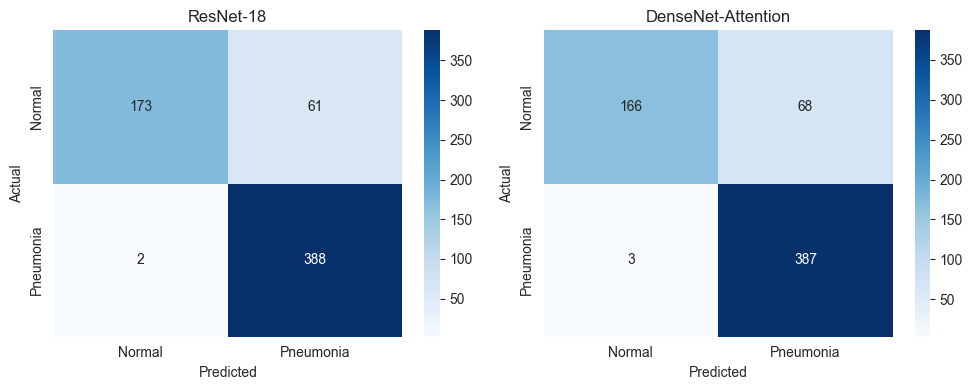

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

plot_confusion_matrix(
    resnet_test["y_true"], resnet_test["y_proba"],
    title="ResNet-18", ax=axes[0],
)
plot_confusion_matrix(
    densenet_test["y_true"], densenet_test["y_proba"],
    title="DenseNet-Attention", ax=axes[1],
)

plt.tight_layout()
plt.savefig("../results/model_confusion_matrices.png", bbox_inches="tight")
plt.show()

## ROC Curve Comparison

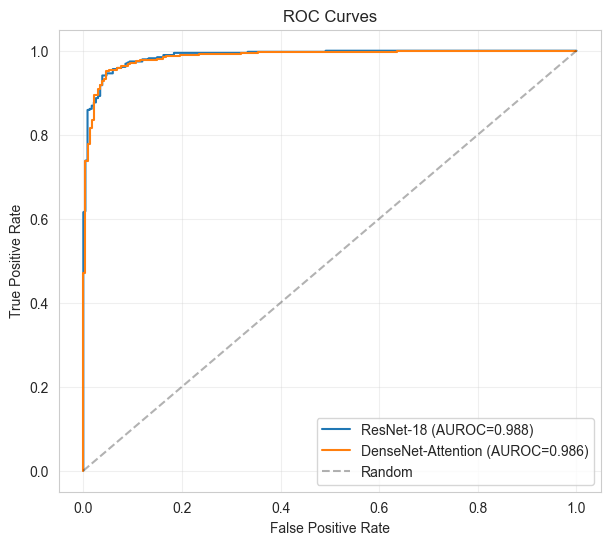

In [9]:
all_results = {
    "ResNet-18": resnet_test,
    "DenseNet-Attention": densenet_test,
}

fig, ax = plt.subplots(figsize=(7, 6))
plot_roc_curve(all_results, ax=ax)
plt.savefig("../results/model_roc_curves.png", bbox_inches="tight")
plt.show()

## Grad-CAM Visualization

Balanced sample of 4 Normal + 4 Pneumonia cases.

In [10]:
test_iter = iter(dataloaders["test"])
all_imgs, all_lbls = [], []
for imgs, lbls in test_iter:
    all_imgs.append(imgs)
    all_lbls.append(lbls)
all_imgs = torch.cat(all_imgs)
all_lbls = torch.cat(all_lbls)

normal_idx = (all_lbls == 0).nonzero(as_tuple=True)[0]
pneumonia_idx = (all_lbls == 1).nonzero(as_tuple=True)[0]

rng = random.Random(42)
selected = (
    [normal_idx[i].item() for i in rng.sample(range(len(normal_idx)), 4)]
    + [pneumonia_idx[i].item() for i in rng.sample(range(len(pneumonia_idx)), 4)]
)

sample_images = all_imgs[selected]
sample_labels = all_lbls[selected]

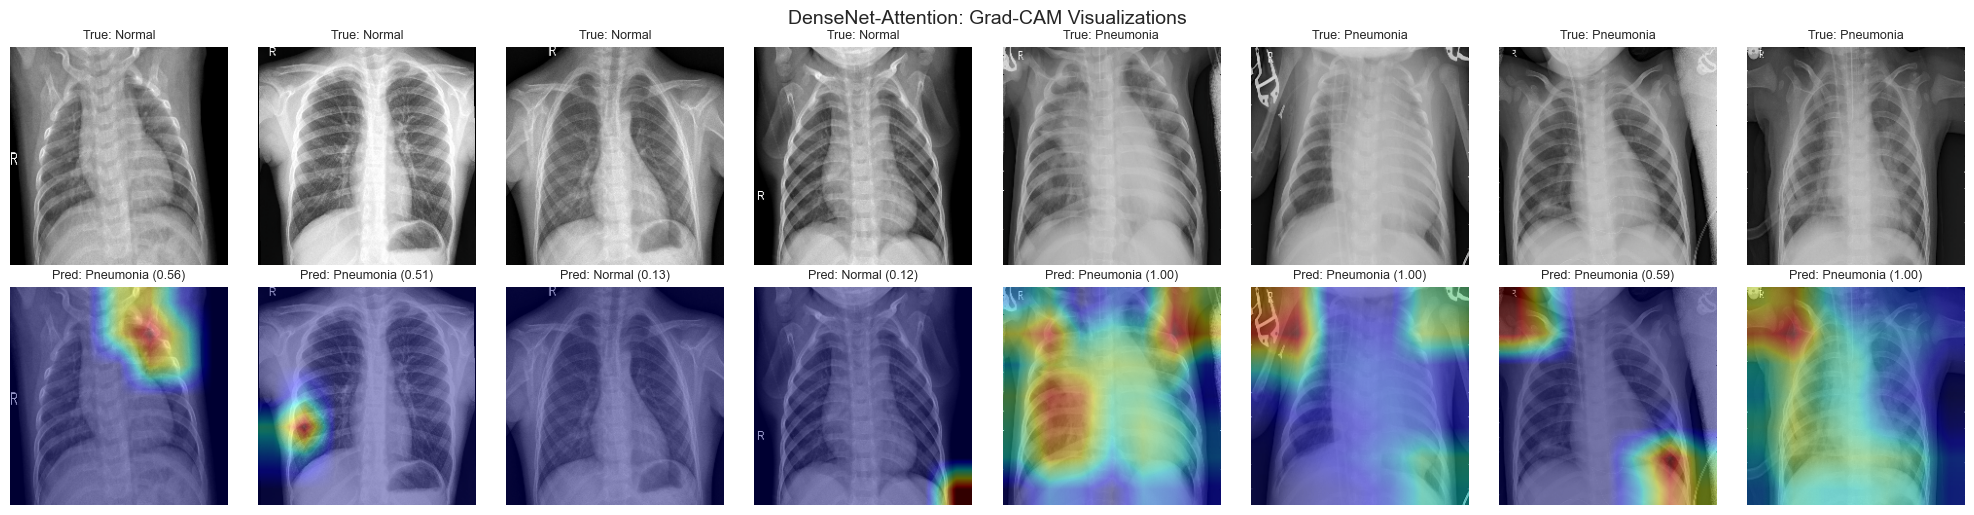

In [11]:
target_layer = densenet_model.backbone[-1]
heatmaps = generate_gradcam(densenet_model, sample_images, target_layer, device)

with torch.no_grad():
    preds = torch.sigmoid(densenet_model(sample_images.to(device)).squeeze()).cpu().numpy()

fig = plot_gradcam_grid(sample_images, heatmaps, sample_labels.numpy(), preds, n_samples=8)
plt.suptitle("DenseNet-Attention: Grad-CAM Visualizations", fontsize=14, y=1.02)
plt.savefig("../results/gradcam_densenet.png", bbox_inches="tight")

# Log to wandb
if USE_WANDB:
    run = wandb_init(name="gradcam-visualizations", job_type="analysis", reinit=True)
    wandb_log_image("gradcam/densenet_attention", fig, run)

plt.show()

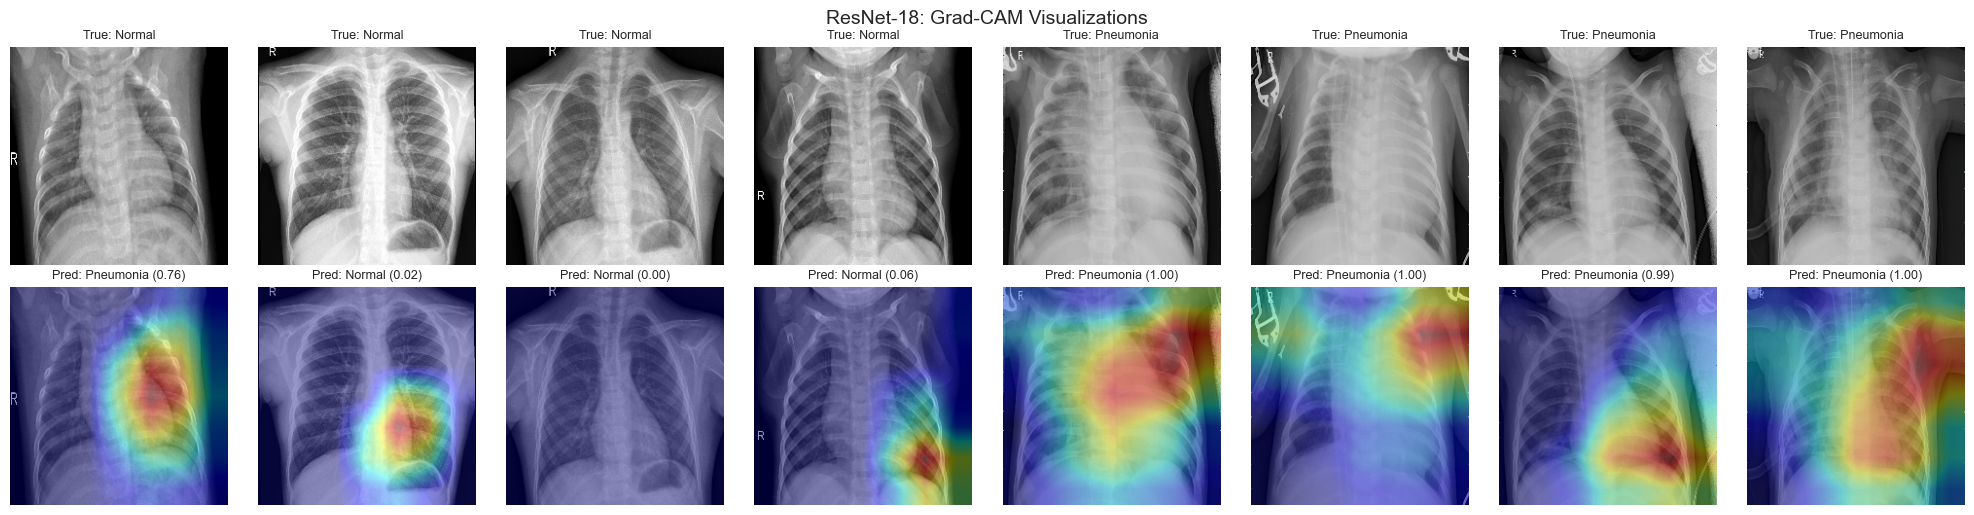

In [12]:
target_layer_resnet = resnet_model.resnet.layer4[-1]
heatmaps_resnet = generate_gradcam(resnet_model, sample_images, target_layer_resnet, device)

with torch.no_grad():
    preds_resnet = torch.sigmoid(resnet_model(sample_images.to(device)).squeeze()).cpu().numpy()

fig = plot_gradcam_grid(sample_images, heatmaps_resnet, sample_labels.numpy(), preds_resnet, n_samples=8)
plt.suptitle("ResNet-18: Grad-CAM Visualizations", fontsize=14, y=1.02)
plt.savefig("../results/gradcam_resnet.png", bbox_inches="tight")

if USE_WANDB:
    wandb_log_image("gradcam/resnet18", fig, run)
    wandb_finish(run)

plt.show()

## Save all results

In [13]:
save_results(
    {
        "resnet18": resnet_test["metrics"],
        "densenet_attention": densenet_test["metrics"],
        "resnet18_threshold": resnet_test["threshold_analysis"],
        "densenet_attention_threshold": densenet_test["threshold_analysis"],
    },
    "model_results",
    output_dir="../results",
)
print("Model results saved.")

Model results saved.
